In [1]:
import pandas as pd
import torch
from scipy.stats import entropy
import transformers
import numpy as np
import json
from transformers import AutoTokenizer, AutoModelForCausalLM,AutoConfig
import sys
sys.path.append("./xai_scripts/tkn_coerce/")
from log_attr_scores import ProbabilisticAttributionScores
import os 
import re
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import HTML
from collections import Counter
import math
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import matplotlib.pyplot as plt
colormap_names = plt.colormaps()

print("Available Matplotlib Colormaps:")
for cmap_name in sorted(colormap_names): 
    print(cmap_name)

Available Matplotlib Colormaps:
Accent
Accent_r
Blues
Blues_r
BrBG
BrBG_r
BuGn
BuGn_r
BuPu
BuPu_r
CMRmap
CMRmap_r
Dark2
Dark2_r
GnBu
GnBu_r
Grays
Greens
Greens_r
Greys
Greys_r
OrRd
OrRd_r
Oranges
Oranges_r
PRGn
PRGn_r
Paired
Paired_r
Pastel1
Pastel1_r
Pastel2
Pastel2_r
PiYG
PiYG_r
PuBu
PuBuGn
PuBuGn_r
PuBu_r
PuOr
PuOr_r
PuRd
PuRd_r
Purples
Purples_r
RdBu
RdBu_r
RdGy
RdGy_r
RdPu
RdPu_r
RdYlBu
RdYlBu_r
RdYlGn
RdYlGn_r
Reds
Reds_r
Set1
Set1_r
Set2
Set2_r
Set3
Set3_r
Spectral
Spectral_r
Wistia
Wistia_r
YlGn
YlGnBu
YlGnBu_r
YlGn_r
YlOrBr
YlOrBr_r
YlOrRd
YlOrRd_r
afmhot
afmhot_r
autumn
autumn_r
binary
binary_r
bone
bone_r
brg
brg_r
bwr
bwr_r
cividis
cividis_r
cool
cool_r
coolwarm
coolwarm_r
copper
copper_r
cubehelix
cubehelix_r
flag
flag_r
gist_earth
gist_earth_r
gist_gray
gist_gray_r
gist_grey
gist_heat
gist_heat_r
gist_ncar
gist_ncar_r
gist_rainbow
gist_rainbow_r
gist_stern
gist_stern_r
gist_yarg
gist_yarg_r
gist_yerg
gnuplot
gnuplot2
gnuplot2_r
gnuplot_r
gray
gray_r
grey
hot
hot_r
hsv
hsv

In [ ]:
def print_sentence_scores(sentence, scores, cmap = plt.cm.coolwarm , vmin= -1, vmax=1, legend=True, end="\n", show_plot = True):

    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
    cmap = cmap

    hex_colors = []
    
    colored_words = []
    for word, score in zip(sentence, scores):
        rgba = list(cmap(norm(score)))
        hex_color = mpl.colors.rgb2hex(rgba) # Convert RGBA to hex
        hex_color = hex_color#+"99"
        hex_colors.append(hex_color)
        colored_words.append(f"<span style='background-color:{hex_color}; padding:2px;'>{word}</span>")
    
    html_sentence = " ".join(colored_words)
    if show_plot:
        display(HTML(html_sentence))
        if legend:
            fig, ax = plt.subplots(figsize=(3.5, 0.1))
            cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal', alpha=0.5)
            cb.set_label("Clamped Score Range", fontsize=8)
            cb.ax.tick_params(labelsize=6)
        print(end=end)
        plt.show()
        
    else:
        return hex_colors, cmap, norm

In [ ]:
path_ = "./xai_scripts/results/one_shot_SUB/"
path = os.path.join(path_, "torch_tensors/")

In [11]:
models_ = !ls ./xai_scripts/results/one_shot_SUB/ALLENAI_*
models_ = Counter(["_".join(i.split("ALLENAI_")[-1].split(".csv")[0].split("_")[:-1]) for i in models_])
all_models = [k for k,v in models_.items() if v==7]
print(all_models)

model_saves_names_dict = {'gemma-3-1b-it': 'google/gemma-3-1b-it' ,
 'gemma-3-270m':"google/gemma-3-270m",
 'gpt2': "openai-community/gpt2",
 'gpt-neo-1.3B': "EleutherAI/gpt-neo-1.3B",
 'Llama-3.2-1B-Instruct': "meta-llama/Llama-3.2-1B-Instruct",
 'MobileLLM-R1-950M': "facebook/MobileLLM-R1-950M",
 'OLMo-2-0425-1B': 'allenai/OLMo-2-0425-1B',
 'OLMo-2-0425-1B-Instruct':'allenai/OLMo-2-0425-1B-Instruct',
 'Qwen2.5-1.5B-Instruct': 'Qwen/Qwen2.5-1.5B-Instruct',
                         "Qwen3-1.7B": "Qwen/Qwen3-1.7B"}

['gemma-3-1b-it', 'gemma-3-270m', 'gpt2', 'gpt-neo-1.3B', 'Llama-3.2-1B-Instruct', 'MobileLLM-R1-950M', 'OLMo-2-0425-1B', 'OLMo-2-0425-1B-Instruct', 'Qwen2.5-1.5B-Instruct', 'Qwen3-1.7B']


In [ ]:
all_models = [
    'gemma-3-1b-it',
 'gpt2',
 'gpt-neo-1.3B',
 'Llama-3.2-1B-Instruct',
 'OLMo-2-0425-1B',
 'OLMo-2-0425-1B-Instruct',
 'Qwen2.5-1.5B-Instruct',
'Qwen3-1.7B']

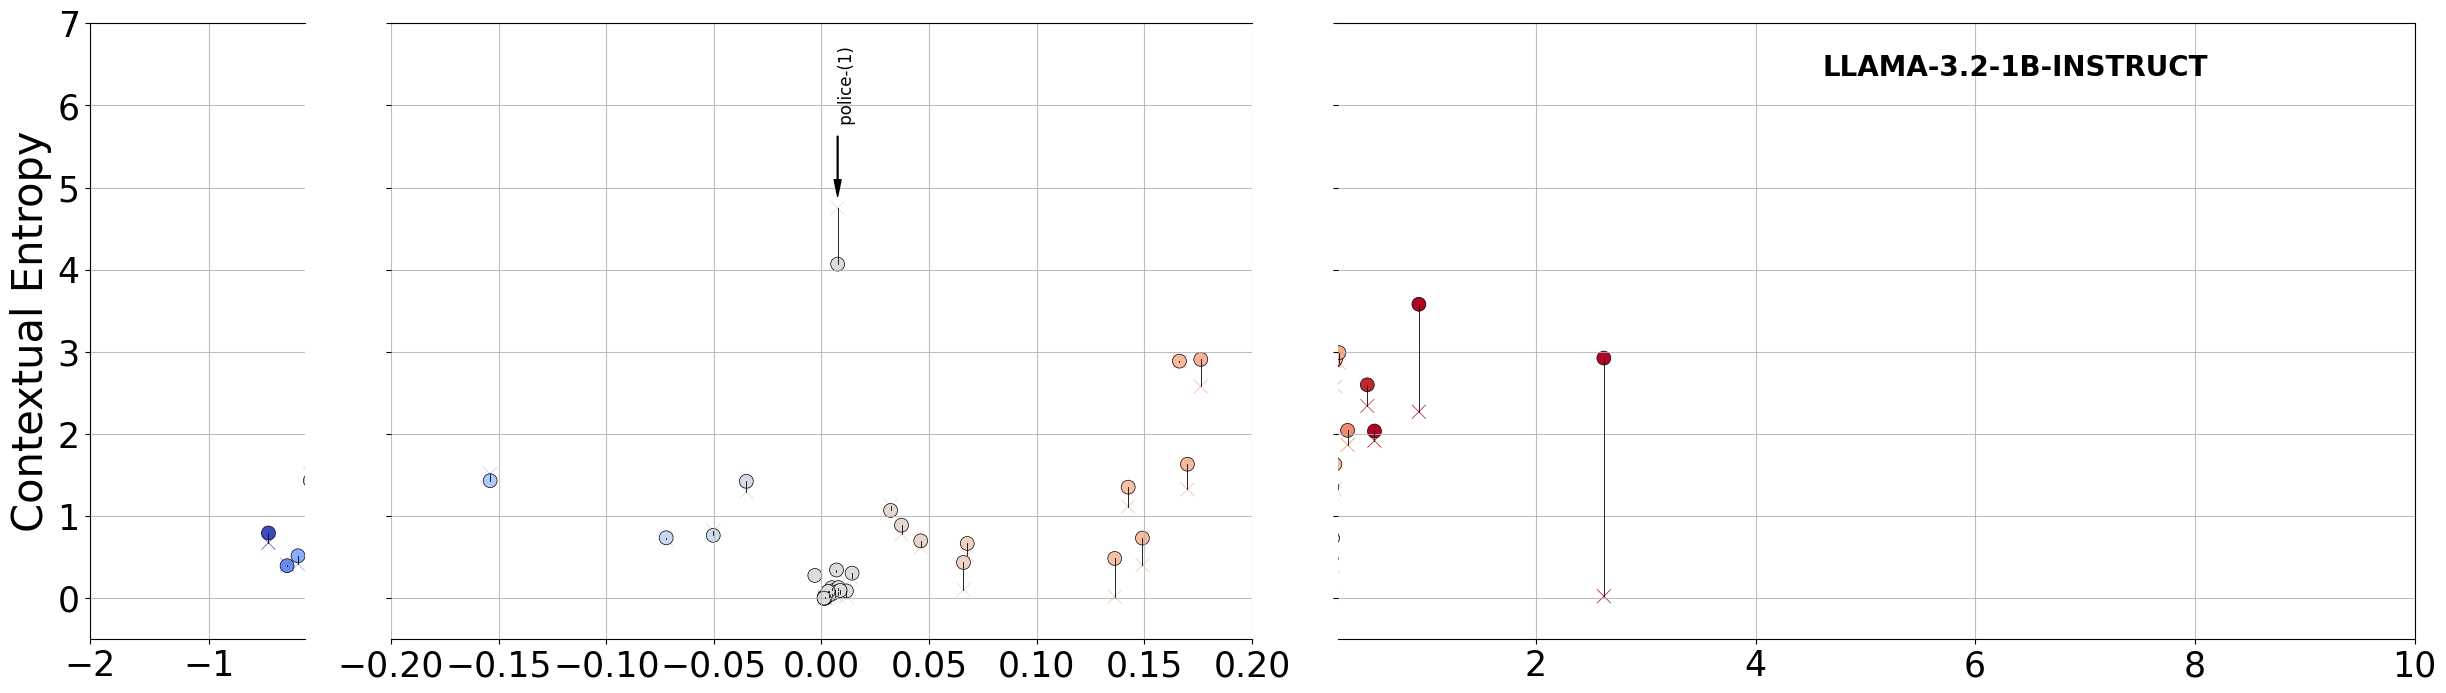

CPU times: user 3.64 s, sys: 270 ms, total: 3.91 s
Wall time: 654 ms


In [ ]:
%%time
all_lines = []
#########################################################
####  MAIN = SUMMARY  - ALL prompts per model_save STRETCHED ###
#########################################################

max_Hs = -10000
asc_ranges_first = [[-2.0, -0.21], [-0.2, 0.2], [0.21, 3.0], [3.1,10.0]]
asc_ranges_ollmo = [[-2.0, -0.21], [-0.2, 0.2], [0.21, 10.0]]
asc_mean_xrange = np.round(np.arange(-2.0, 11.0, 0.01), 2).tolist() 

for model_save in all_models[:]:

    if model_save == "OLMo-2-0425-1B":
        asc_ranges = asc_ranges_ollmo
    else: 
        asc_ranges = asc_ranges_first
    fig, (ax_left, ax_mid, ax_right) = plt.subplots(
        1, 3,
        sharey=True,
        figsize=(30, 8),
        gridspec_kw={
            "width_ratios": [1, 4, 5],  # stretch the middle
            "wspace": 0.12
        }
    )
    
    # Remove horizontal space between axes
    fig.subplots_adjust(hspace=1)#(hspace=0.03)

    axis_col = 0
    asc_mean_lines = [0] * len(asc_mean_xrange)
    asc_ranges_counts = [0] * len(asc_ranges) # denom of mean
    
    for s_id in range(3,4):

        path_model = os.path.join(path, model_save)

        data_folder_muilf = f"ALLENAI_MUILF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_mulf = f"ALLENAI_MULF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_asc = f"ALLENAI_{model_save}_{s_id}.csv"
        
        
        with open( os.path.join(path_, data_folder_asc), "r") as f:
            freadlines = f.readlines()
            lll = [i.replace("<|endoftext|>", " endoftext ") for idx, i in enumerate(freadlines) if idx != 0 and "LogA" not in i]
            lll = [re.sub(r'\<\|([a-z\_]+)\|\>',r"<\1>", i) for i in lll]
            lines1 = [i.replace("\n", " ") for idd, i in enumerate(lll) if i != "\n" and len(i.split("|"))>7]
            if "time" in freadlines[0].split("|")[-1]:
                print(f"{model_save}, time")
            if "Qwen3" in model_save:
                lines = [float(i.split("|")[-2].split("\n")[0]) for i in lines1[:]]
            else:
                lines = [float(i.split("|")[-1].split("\n")[0]) for i in lines1[:]]
            lines2 = [i.split("|")[4] for i in lines1[:]]
            
        
        filepaths_muilf = [i for i in os.listdir(path_model) if re.match(data_folder_muilf,i )]
        max_fp_muilf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_muilf])
        fp_muilf = [os.path.join(path_model, data_folder_muilf.replace(".*", str(i))) for i in range(max_fp_muilf + 1)]
        
        filepaths_mulf = [i for i in os.listdir(path_model) if re.match(data_folder_mulf,i )]
        max_fp_mulf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_mulf])
        fp_mulf = [os.path.join(path_model, data_folder_mulf.replace(".*", str(i))) for i in range(max_fp_mulf + 1)]
        
        
        
        ent_list = []
        ent_list_I = []
        scores = []
        for xid, x_no_resp in enumerate(fp_muilf):
            
            ent_resp = torch.load(fp_mulf[xid]) # with Response
            ent_no_resp = torch.load(x_no_resp) # does not contain Response 
        
            ent_num = torch.nn.functional.softmax( ent_resp - torch.max(ent_resp), dim = 0  ) 
            ent_denom = torch.nn.functional.softmax( ent_no_resp - torch.max(ent_no_resp), dim = 0) 
            
            ent_list.append(ent_num)
            ent_list_I.append(ent_denom) #without
                
        if "<" in lines2[0] and ">" in lines2[0]:
            lines2 = lines2[1:]
            ent_list_I = ent_list_I[1:]
            ent_list = ent_list[1:]
            lines = lines[1:]
            all_lines.append(lines2)
            
        
        pk_I = torch.stack(ent_list_I, dim = 0)
        pk = torch.stack(ent_list, dim = 0)
        H_I_ = entropy(pk_I.float().numpy(), axis=-1)
        H_I = H_I_ 
        H_ = entropy(pk.float().numpy(), axis=-1)
        H = H_ 
        
        asc = np.array(lines)

        assert len(asc) == len(lines2)
        assert(H.shape[0] == pk.shape[0])
                
        prompt_main = lll[1].split("|")[1]
        response_main = lll[1].split("|")[2]
        
        max_y = 0.5
        min_y = -0.5

        ecolor = 'tab:red'
        ecolor = 'black'
        ecolors, cbarMap, cbarNorm = print_sentence_scores(lines2, asc, vmin=min_y, vmax=max_y, show_plot=False)


        ######################
        ### MEAN LINES
        ######################
        for idd_asc_range, asc_range in enumerate(asc_ranges):
            subset = H_I[np.where( (asc>=asc_range[0]) & (asc<=asc_range[1]) )]
            if len(subset) == 0:
                continue
            mean_value = sum(subset) 
            asc_ranges_counts[idd_asc_range] = asc_ranges_counts[idd_asc_range] + len(subset)
            sum_list1 = asc_mean_lines[asc_mean_xrange.index(asc_range[0]):asc_mean_xrange.index(asc_range[1])]
            sum_list2 = [mean_value] * (asc_mean_xrange.index(asc_range[1]) - asc_mean_xrange.index(asc_range[0]))
            sum_list = [x + y for x, y in zip(sum_list1, sum_list2)]
            asc_mean_lines[asc_mean_xrange.index(asc_range[0]):asc_mean_xrange.index(asc_range[1])] = sum_list
    
        
        for axs in (ax_left, ax_mid, ax_right):
            axs.scatter(asc, H, s=100,  marker="x", label="Prompt + Response", c=asc, cmap=cbarMap, norm=cbarNorm, linewidths=0.5, edgecolors="black")
            
            axs.grid(True, linestyle='-', alpha=0.8)
            axs.tick_params(axis='y', labelcolor=ecolor, labelsize=25 )
            
            ecolor = 'tab:green'
            ecolor = 'black'
            ax2 = axs 
           
            sc = ax2.scatter(asc, H_I, s=100, marker="o", label="Prompt", c=asc, cmap=cbarMap, norm=cbarNorm, linewidths=0.5, edgecolors="black")
            
            for hh in range(len(H)):
                ax2.plot([asc[hh],asc[hh]], [H[hh], H_I[hh]], lw=0.6, color = "black")
            
           
        ax_left.tick_params(axis='y', labelcolor=ecolor, labelsize=25 )
        ax_left.set_ylabel('Contextual Entropy', color=ecolor,fontsize=30)
        ax_left.set_ylim(bottom=-0.5, top=7) 
        
        # Set x-limits for each segment
        ax_left.set_xlim(-2, -0.2)
        ax_mid.set_xlim(-0.2, 0.2)
        ax_right.set_xlim(0.2, 10 )
        
        # Hide spines between axes
        ax_left.spines["right"].set_visible(False)
        ax_mid.spines["left"].set_visible(False)
        ax_mid.spines["right"].set_visible(False)
        ax_right.spines["left"].set_visible(False)
        
        # Hide ticks where axes touch
        ax_left.tick_params(labelright=False, labelsize=25)
        ax_mid.tick_params(labelleft=False, labelright=False, labelsize=25)
        ax_right.tick_params(labelleft=False, labelsize=25)

        #TITLE
        if "llama" in model_save.lower():
            ax_right.text(0.45, 0.95, model_save.upper(),
            transform=ax2.transAxes, 
            fontsize=20, fontweight="bold",
            va="top", ha="left", color="black")
        else:
            ax_right.text(0.5, 0.95, model_save.upper(),
                transform=ax2.transAxes, 
                fontsize=20, fontweight="bold",
                va="top", ha="left", color="black")


        ##############################
        ### ANNOTATE HIGH ASC VALS
        ##############################
        for spos in np.where( asc>=4 )[0]:
            assert asc.shape[0] == len(lines2)
        
            if asc[spos] >= 0:
                yy = H_I[spos] if H_I[spos] > H[spos] else H[spos]
                ax_right.annotate(f"{lines2[spos]}", xy=(asc[spos], yy + 0.1 ), xytext=(asc[spos], yy+1),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=0.6, headwidth=5),
                             fontsize=12, rotation=90,color='black')


        for spos in np.where( (asc>=-0.2) & (asc<=0.2) )[0]:
            assert asc.shape[0] == len(lines2)
        
            if H_I[spos] >4:
                yy = H_I[spos] if H_I[spos] > H[spos] else H[spos]
                ax_mid.annotate(f"{lines2[spos]}-({spos})", xy=(asc[spos], yy + 0.1 ), xytext=(asc[spos], yy+1),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=0.6, headwidth=5),
                             fontsize=12, rotation=90,color='black')

        max_Hs = max(max_Hs, max(H), max(H_I))
    
    plt.tight_layout()
    
    plt.show()
        

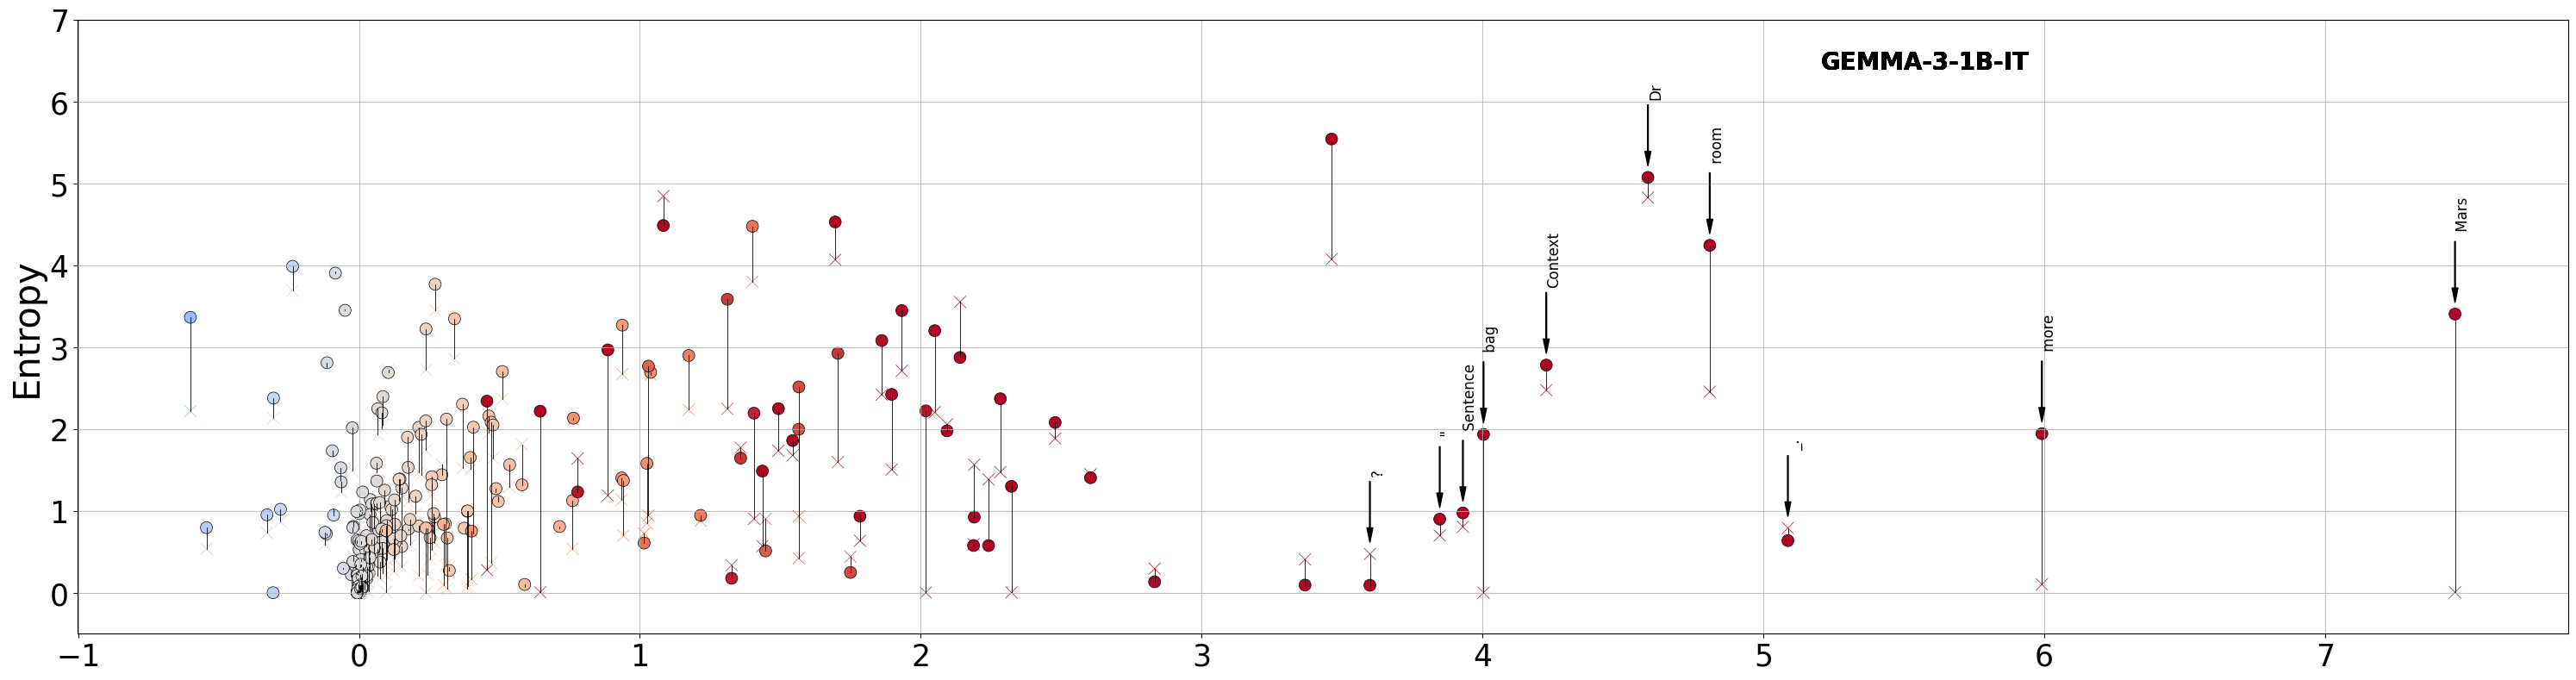

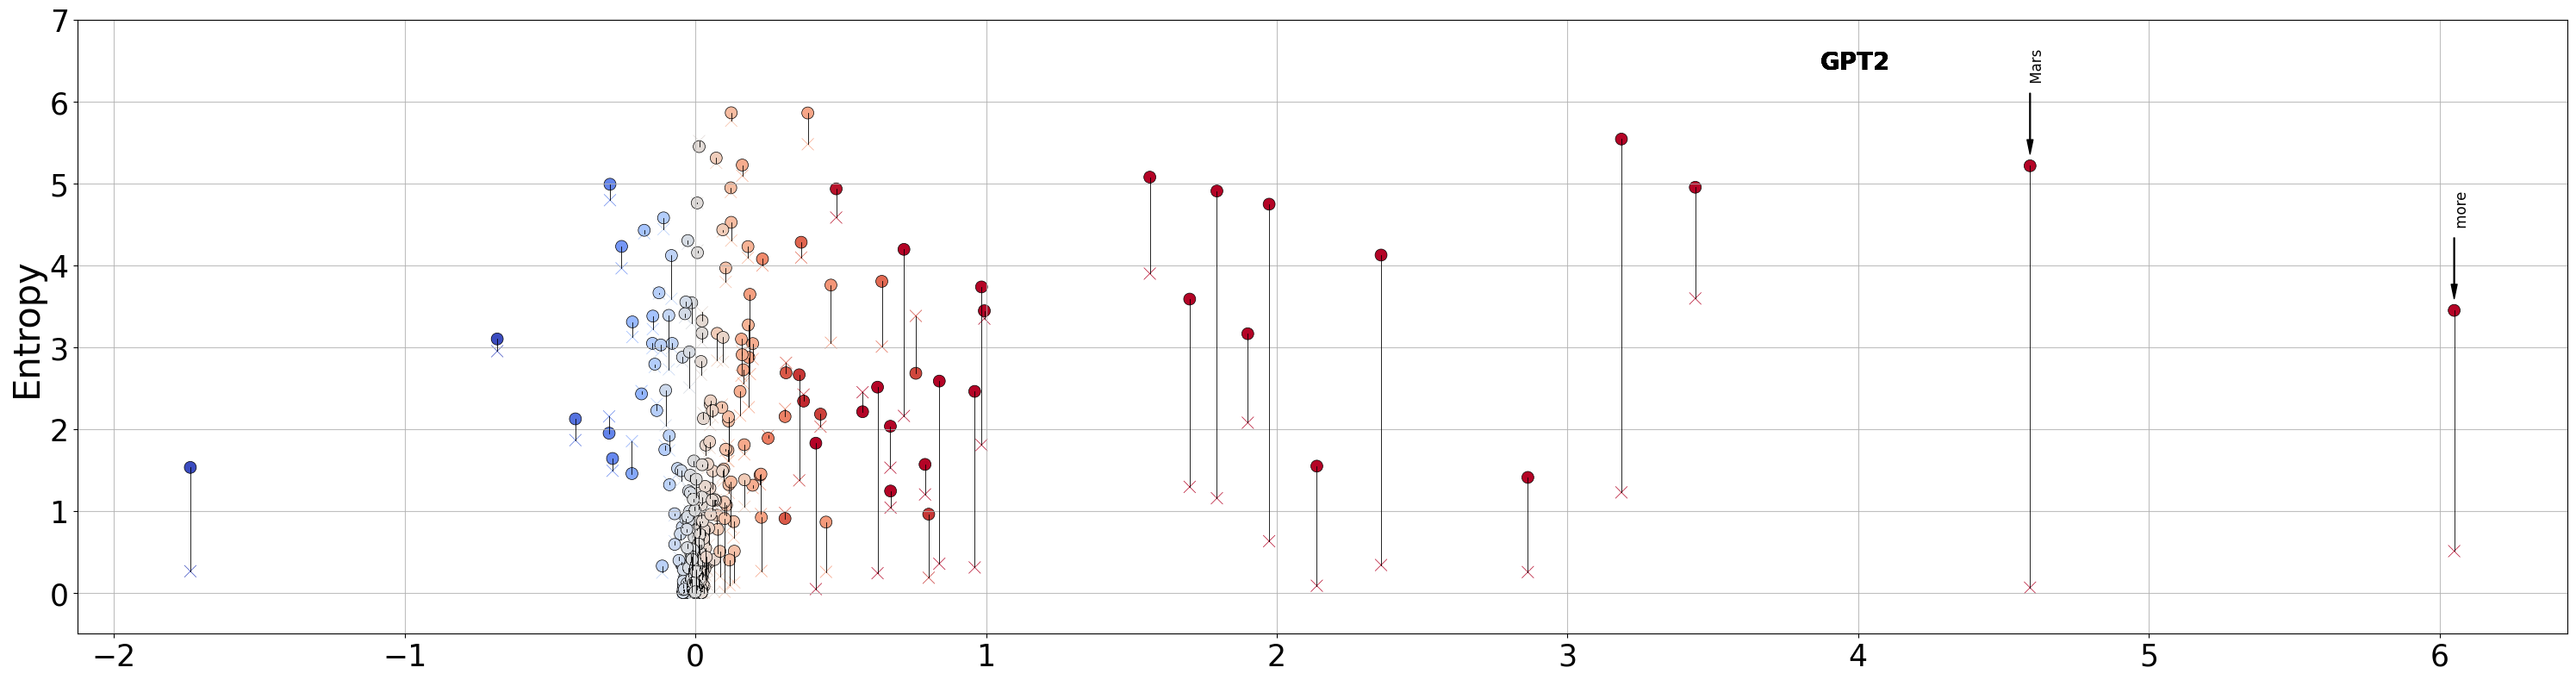

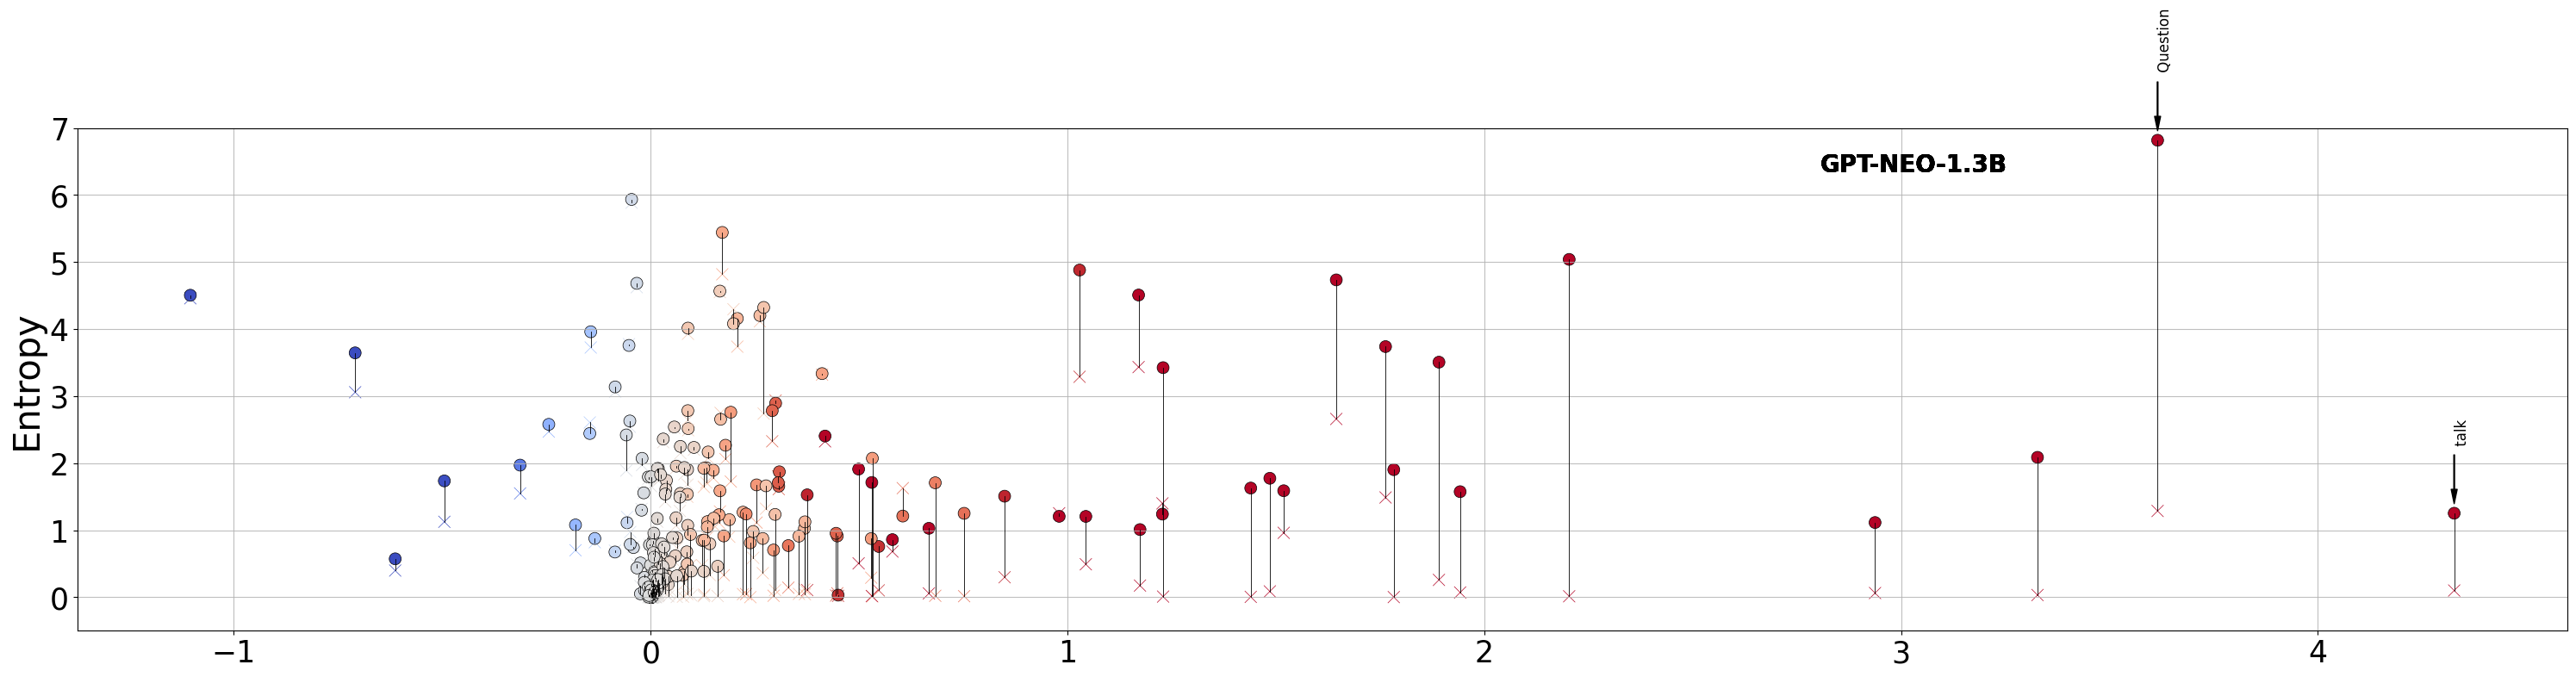

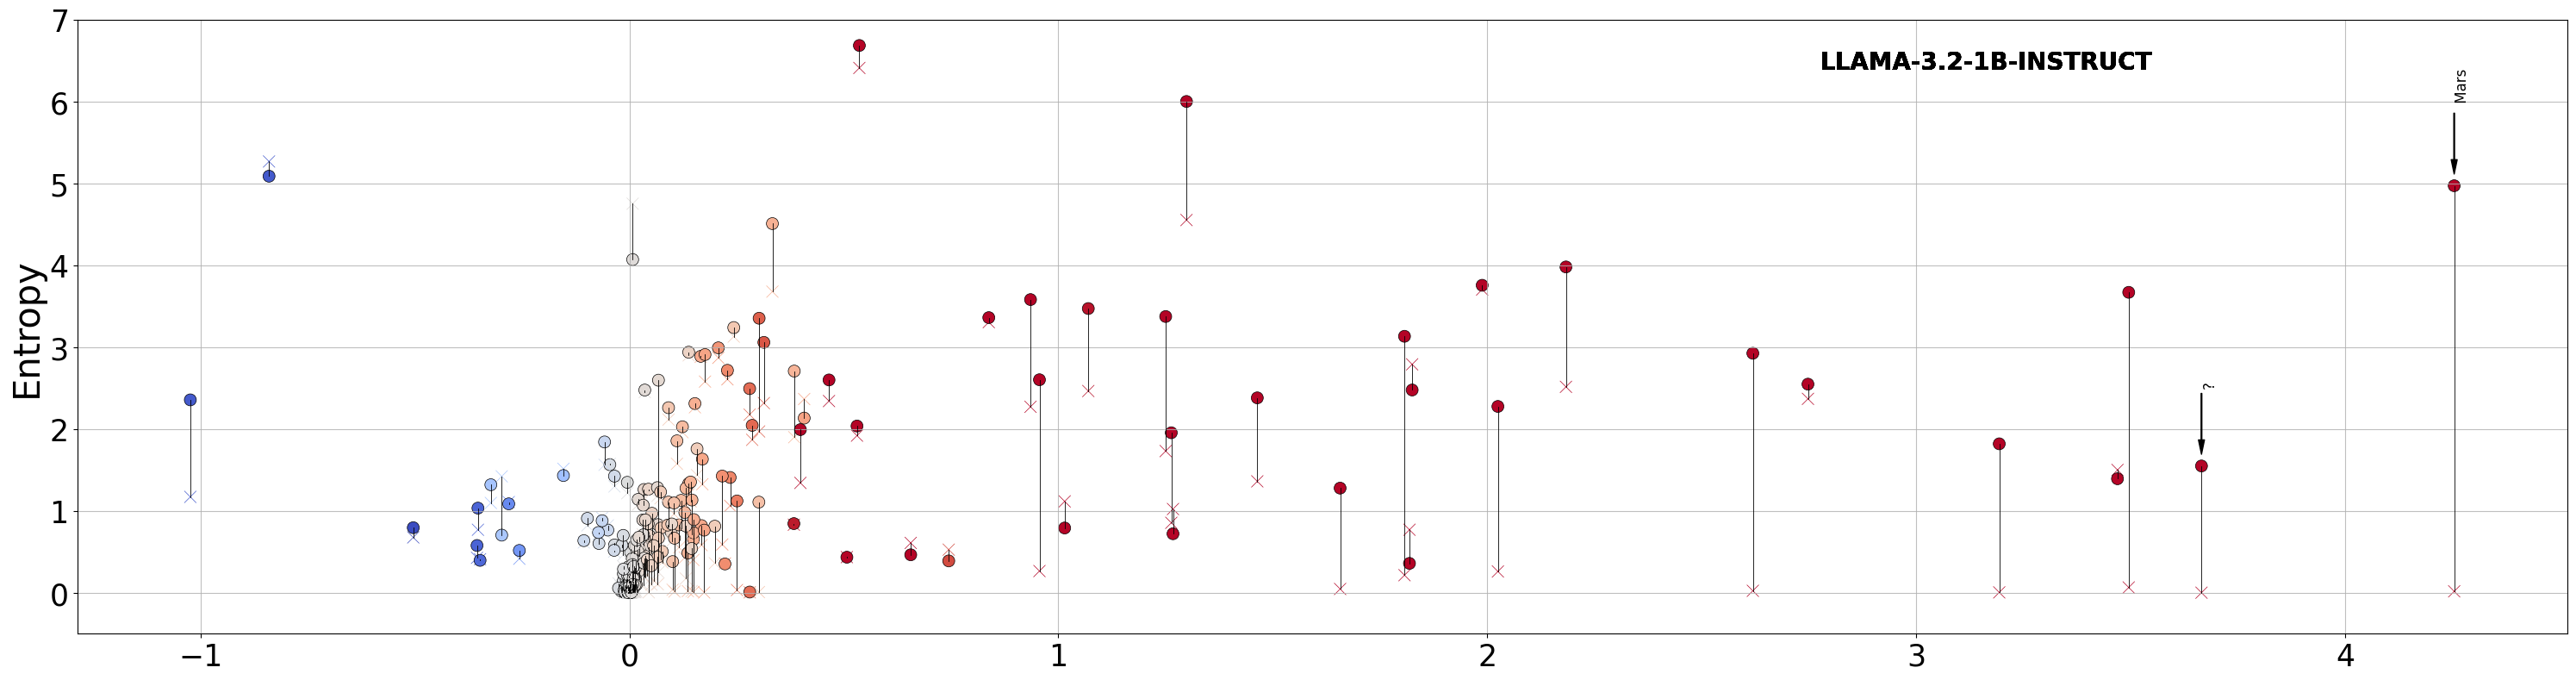

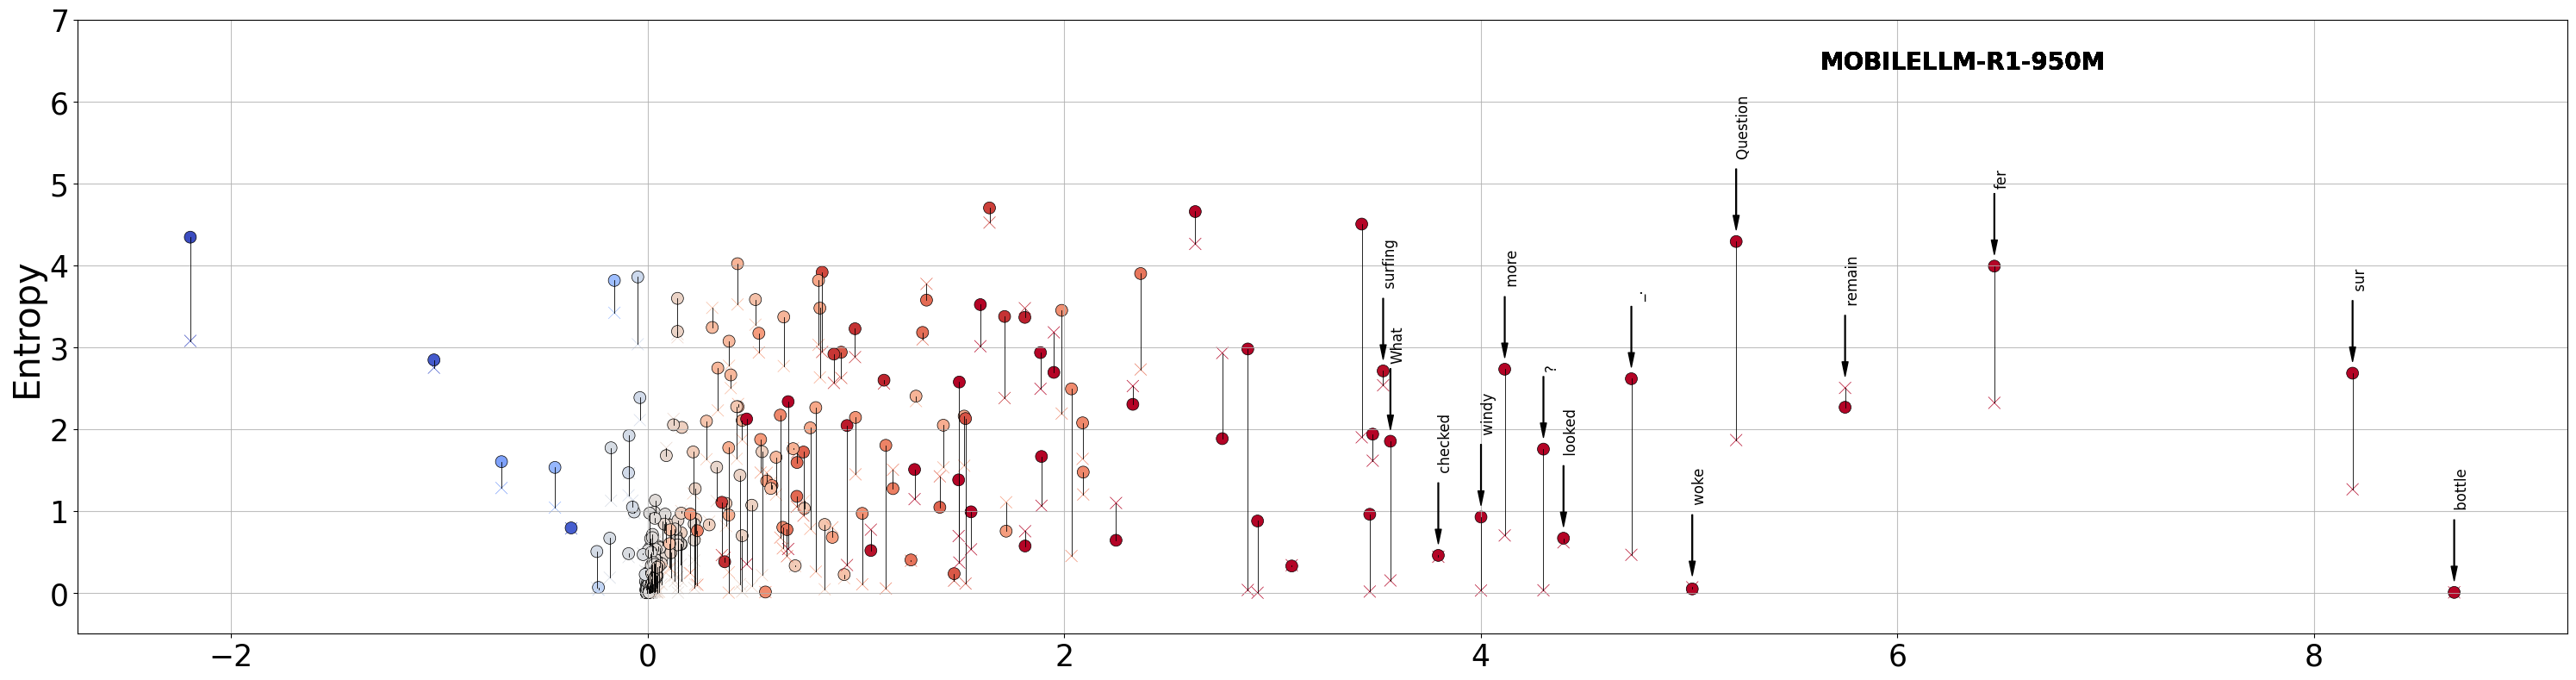

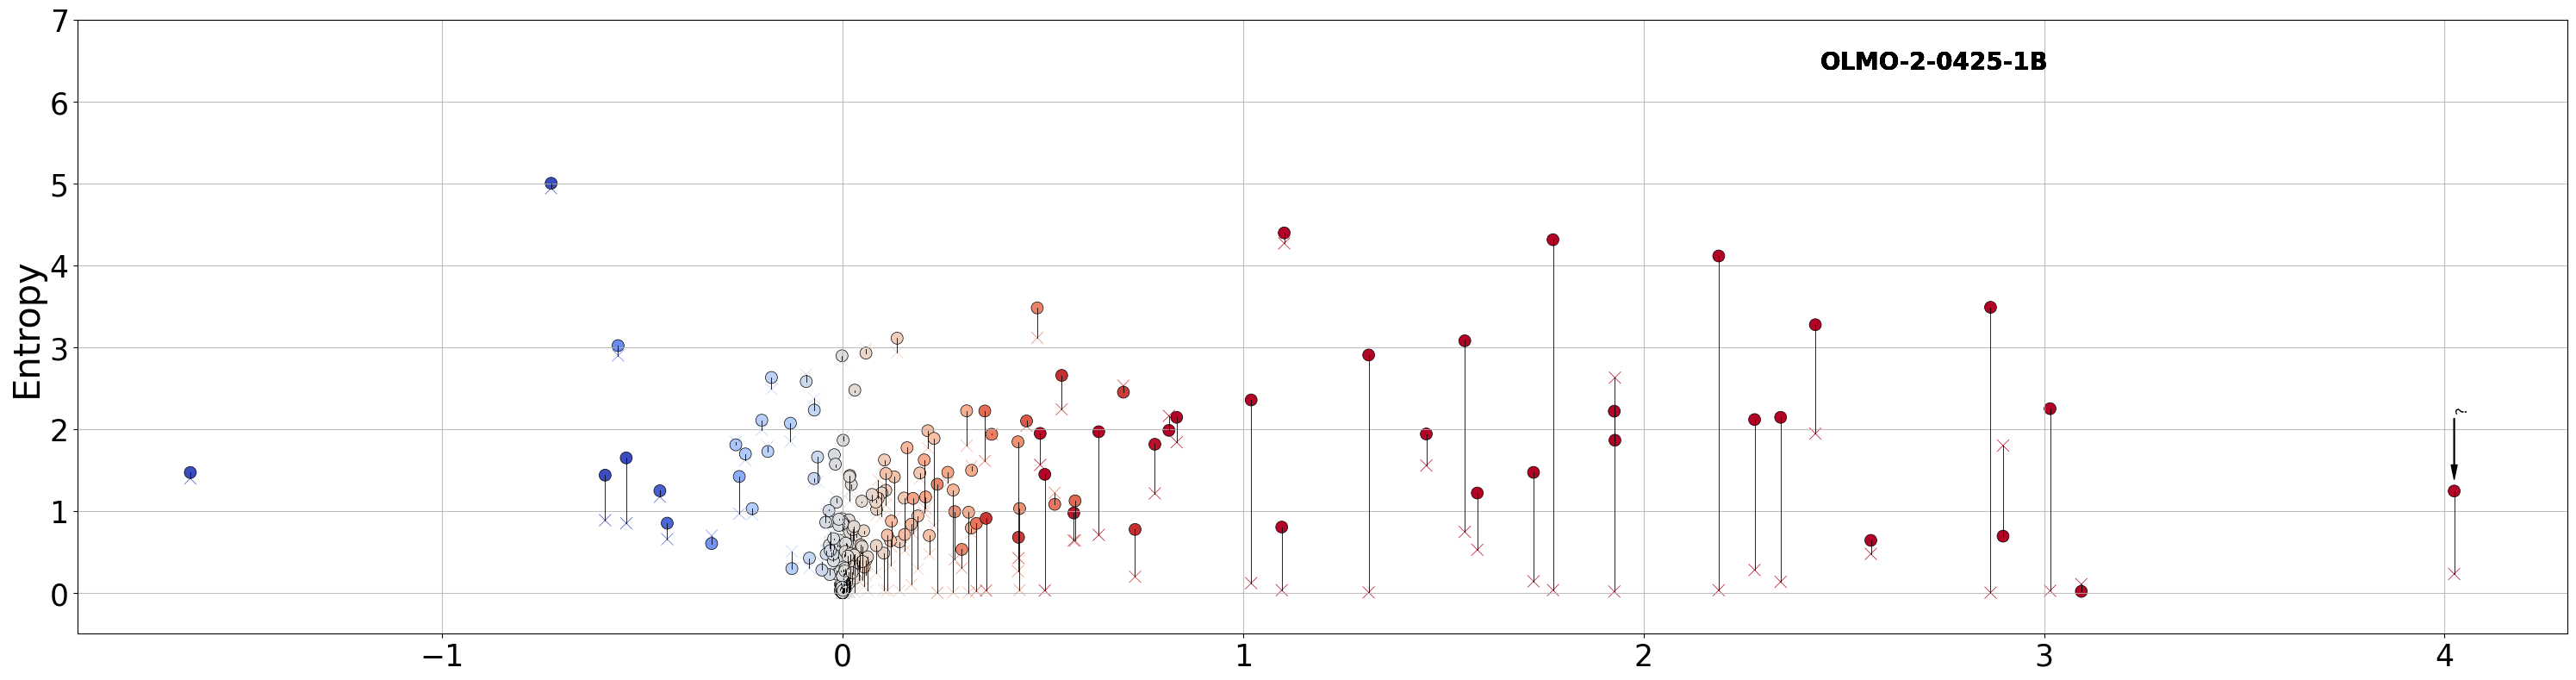

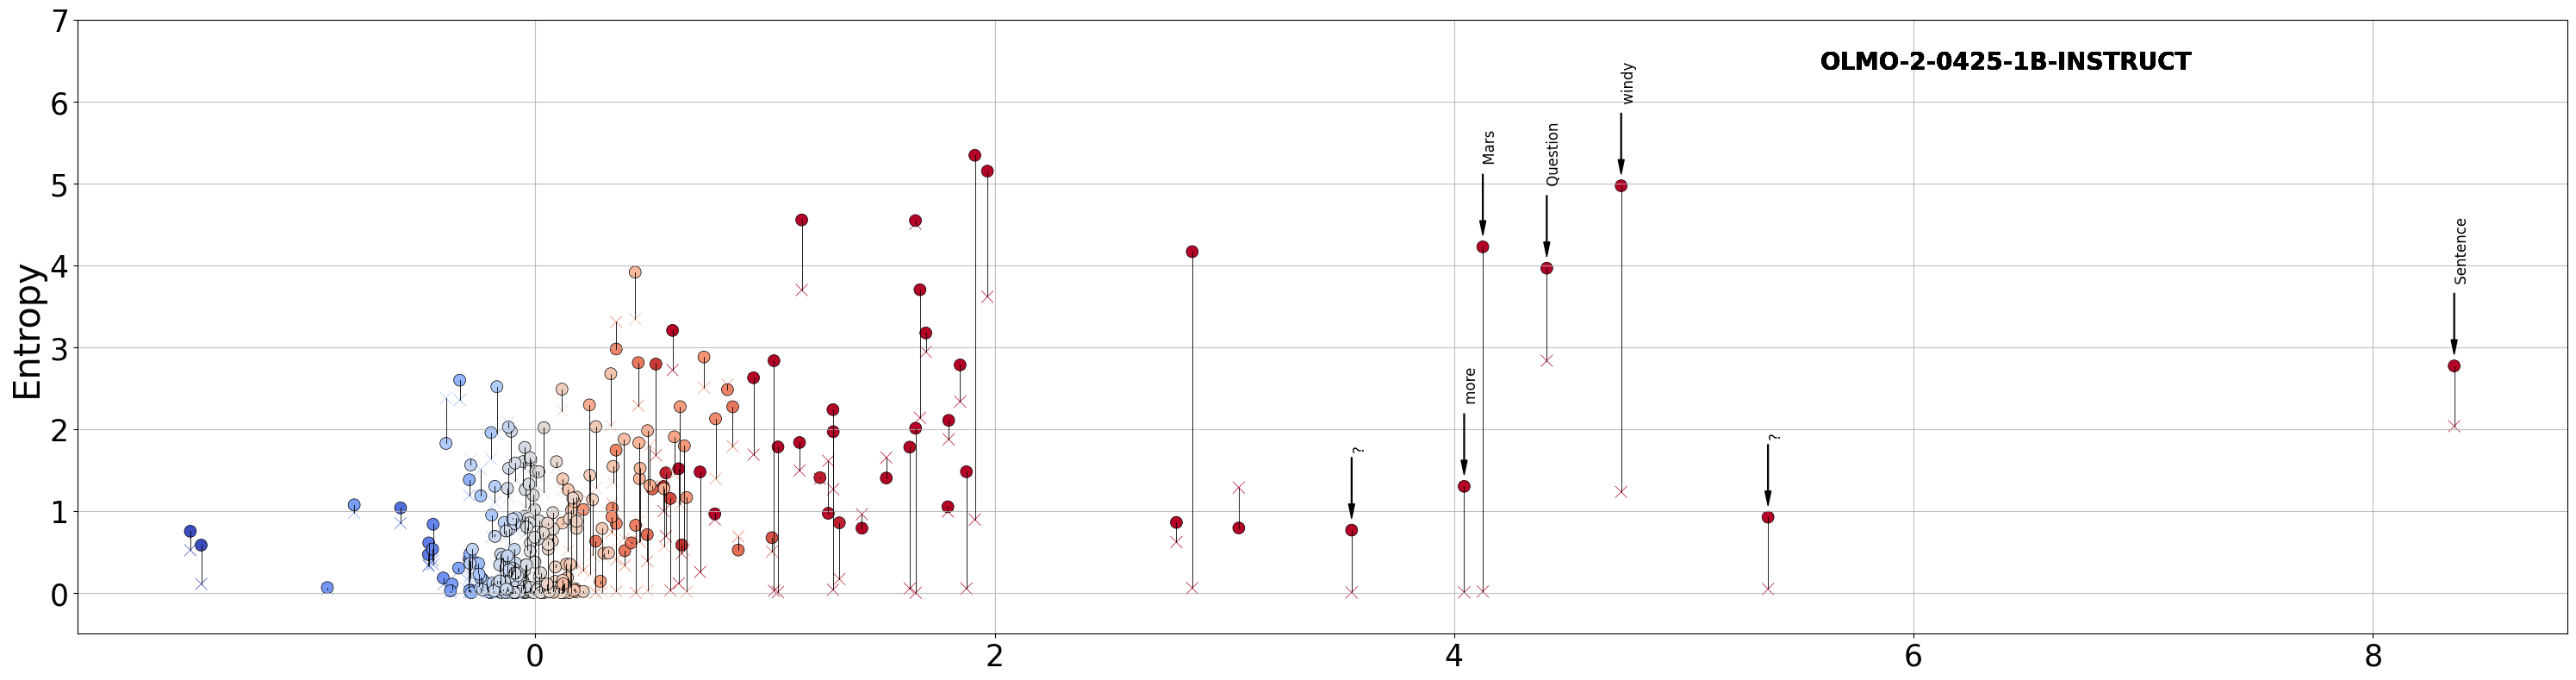

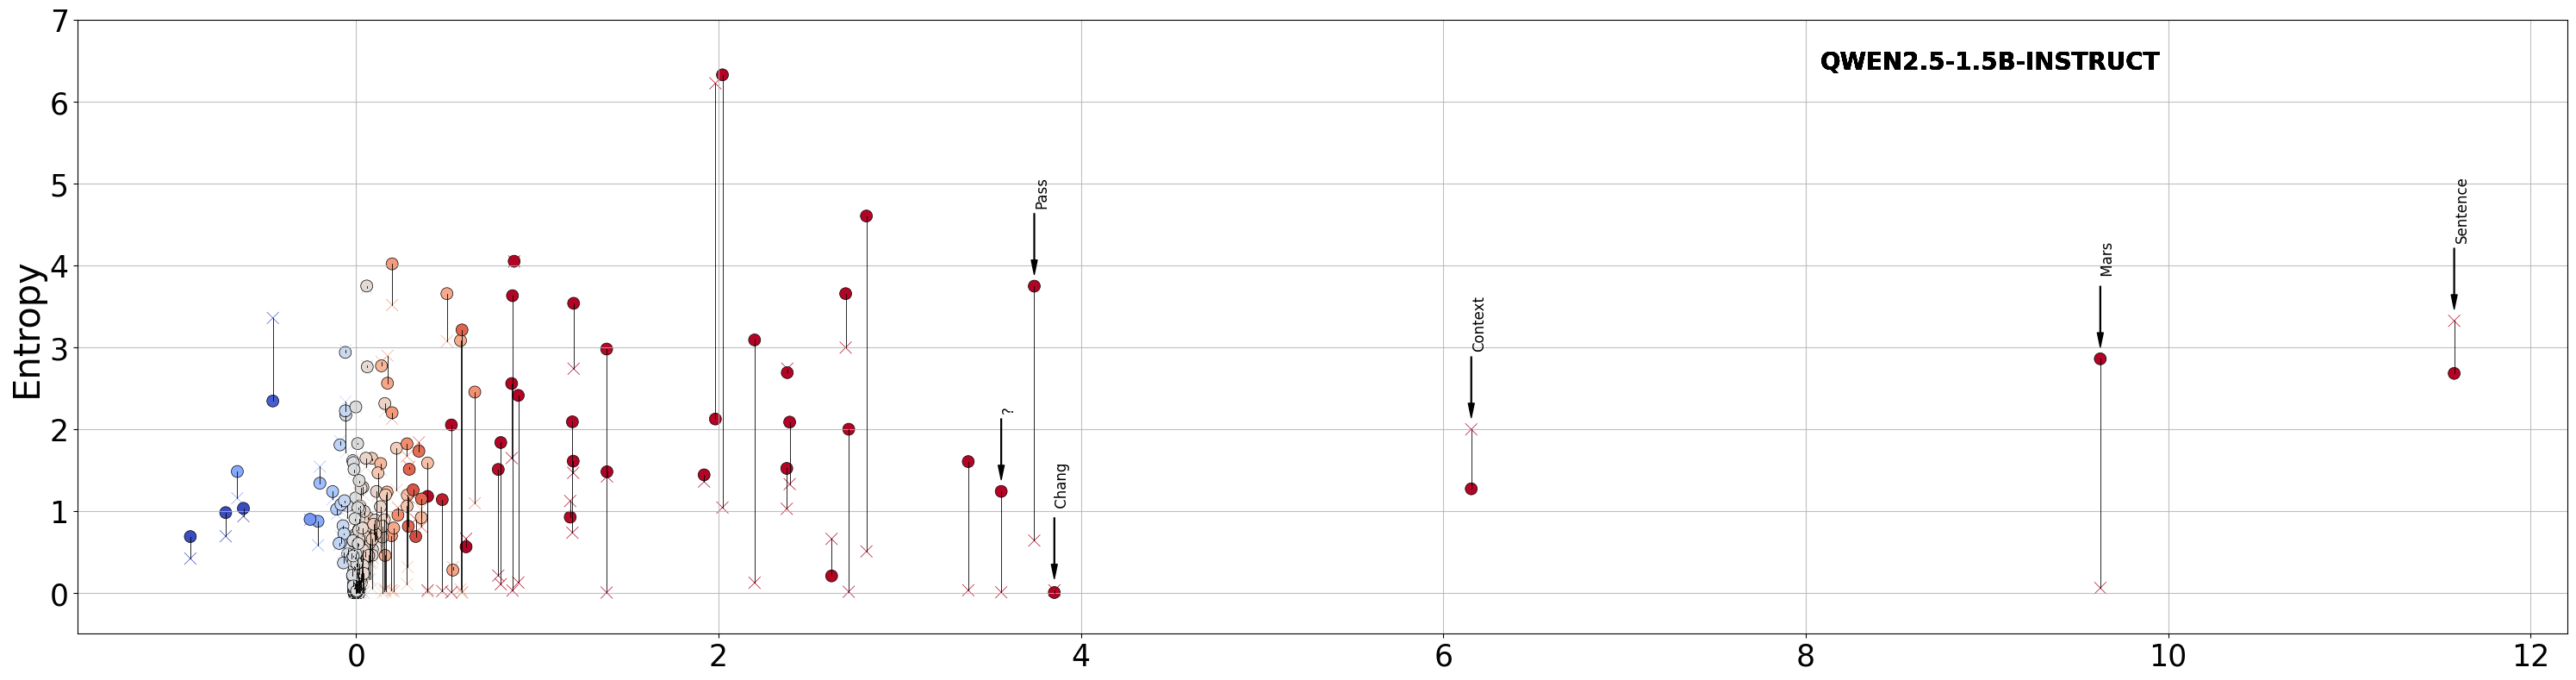

CPU times: user 18min 9s, sys: 12.2 s, total: 18min 22s
Wall time: 2min 52s


In [14]:
%%time
#########################################################
####  MAIN = SUMMARY  - ALL prompts per model_save ###
#########################################################

max_Hs = -10000

for model_save in all_models[:]:
    fig, axs = plt.subplots(1, 1, sharex=False, figsize=(30, 8))
    # Remove horizontal space between axes
    fig.subplots_adjust(hspace=1)#(hspace=0.03)

    axis_col = 0

    for s_id in range(7):

        # print(f"Processing model {model_save}")
        path_model = os.path.join(path, model_save)
        # print("model path",path_model)

        data_folder_muilf = f"ALLENAI_MUILF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_mulf = f"ALLENAI_MULF_{model_save}_MU.*_SID{s_id}.pt"
        data_folder_asc = f"ALLENAI_{model_save}_{s_id}.csv"
        
        
        with open( os.path.join(path_, data_folder_asc), "r") as f:
            lll = [i.replace("<|endoftext|>", " endoftext ") for idx, i in enumerate(f.readlines()) if idx != 0 and "LogA" not in i]
            lll = [re.sub(r'\<\|([a-z\_]+)\|\>',r"<\1>", i) for i in lll]
            lines1 = [i.replace("\n", " ") for idd, i in enumerate(lll) if i != "\n" and len(i.split("|"))>7]
            # print(len(lines1))
            lines = [float(i.split("|")[-1].split("\n")[0]) for i in lines1[:]]
            lines2 = [i.split("|")[4] for i in lines1[:]]
        
        # if s_id == 0:
        #     assert len(lines2) == 53
        
        filepaths_muilf = [i for i in os.listdir(path_model) if re.match(data_folder_muilf,i )]
        max_fp_muilf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_muilf])
        fp_muilf = [os.path.join(path_model, data_folder_muilf.replace(".*", str(i))) for i in range(max_fp_muilf + 1)]
        
        filepaths_mulf = [i for i in os.listdir(path_model) if re.match(data_folder_mulf,i )]
        max_fp_mulf = max([int(ii.split("_")[-2].split("MU")[1]) for ii in filepaths_mulf])
        fp_mulf = [os.path.join(path_model, data_folder_mulf.replace(".*", str(i))) for i in range(max_fp_mulf + 1)]
        
        
        
        ent_list = []
        ent_list_I = []
        scores = []
        for xid, x_no_resp in enumerate(fp_muilf):
            
            ent_resp = torch.load(fp_mulf[xid]) # with Response
            ent_no_resp = torch.load(x_no_resp) # does not contain Response 
        
            ent_num = torch.nn.functional.softmax( ent_resp - torch.max(ent_resp), dim = 0  ) 
            ent_denom = torch.nn.functional.softmax( ent_no_resp - torch.max(ent_no_resp), dim = 0) 
            
            ent_list.append(ent_num)
            ent_list_I.append(ent_denom) #without
                
        if "<" in lines2[0] and ">" in lines2[0]:
            lines2 = lines2[1:]
            ent_list_I = ent_list_I[1:]
            ent_list = ent_list[1:]
            lines = lines[1:]
            
        
        pk_I = torch.stack(ent_list_I, dim = 0)
        pk = torch.stack(ent_list, dim = 0)
        H_I_ = entropy(pk_I.float().numpy(), axis=-1)
        H_I = H_I_ #np.nan_to_num(H_I_, nan=0.0)
        H_ = entropy(pk.float().numpy(), axis=-1)
        H = H_ #np.nan_to_num(H_, nan=0.0)
        
        asc = np.array(lines)

        assert len(asc) == len(lines2)
        assert(H.shape[0] == pk.shape[0])
        
        # print("done", H_I.shape, H.shape, pk.shape, len(lines2))
        
        prompt_main = lll[1].split("|")[1]
        response_main = lll[1].split("|")[2]
        
        max_y = 0.4
        min_y = -0.4

        while True:
            if np.where( ((asc>=max_y) | (asc<=min_y)) )[0].shape[0] > 5:
                min_y-=0.1
                max_y+=0.1
            else:
                break
        
        
        # print("axis_col", axis_col)
        ecolor = 'tab:red'
        ecolor = 'black'
        ecolors, cbarMap, cbarNorm = print_sentence_scores(lines2, asc, vmin=min_y, vmax=max_y, show_plot=False)
        # axs[axis_col].scatter([*range(len(H))], H, s=250,  marker="o", label="Entropy", color=ecolor)
        axs.scatter(asc, H, s=100,  marker="x", label="Prompt + Response", c=asc, cmap=cbarMap, norm=cbarNorm, linewidths=0.5, edgecolors="black")
        # axs.plot([*range(len(H))], [0]*len(H), lw=0.6, color = ecolor)
        axs.grid(True, linestyle='-', alpha=0.8)
        # axs.tick_params(axis='y', which='both', left=True, labelleft=True, labelcolor=ecolor, labelsize=15 )
        axs.tick_params(axis='y', labelcolor=ecolor, labelsize=25 )
        # axs.set_ylabel('Entropy - Response', color=ecolor,fontsize=18)
        # axs.set_ylim(bottom=min(H)-1, top=max(H)+1) 
        # axs.set_title(model_save.upper()+f"{min_y}-{max_y}")
        # axs.legend(fontsize=20)
        
        ecolor = 'tab:green'
        ecolor = 'black'
        ax2 = axs #axs.twinx()
        # axis_col+=1
        # print("axis_col1", axis_col)
        # axs.scatter([*range(len(H))], H_I - H, s=250, marker="x", label="Entropy", color=ecolor)
        sc = ax2.scatter(asc, H_I, s=100, marker="o", label="Prompt", c=asc, cmap=cbarMap, norm=cbarNorm, linewidths=0.5, edgecolors="black")
        
        for hh in range(len(H)):
            ax2.plot([asc[hh],asc[hh]], [H[hh], H_I[hh]], lw=0.6, color = "black")
        
        # ax2.plot([*range(len(H))], [0]*len(H), lw=0.6, color = ecolor)
        # ax2.grid(True, linestyle='-', alpha=0.8)
        # ax2.tick_params(axis='y',  which='both', right=True, labelright=True, labelcolor=ecolor, labelsize=15 )
        ax2.tick_params(axis='y', labelcolor=ecolor, labelsize=25 )
        
        ax2.set_ylabel('Entropy', color=ecolor,fontsize=30)
        ax2.set_ylim(bottom=-0.5, top=7) 
        # ax2.set_title(model_save.upper())
        # ax2.legend(fontsize=20)

        
        
        
        # plt.setp(axs[axis_col].get_xticklabels(), rotation=90,fontsize=12)
        
        # COLOR BAR
        # cbar = plt.colorbar(sc,pad=0.01)
        # cbar.set_label("LPAS (Clamped)", fontsize=20)
        # cbar.ax.tick_params(labelsize=20, length=8, width=2)

        #TITLE

        ax2.text(0.7, 0.95, model_save.upper(),
            transform=ax2.transAxes, 
            fontsize=20, fontweight="bold",
            va="top", ha="left", color="black")
 

        # axs[axis_col].set_xticks(np.arange(len(lines2)))
        axs.tick_params(axis='x', labelsize=25 )
        # axs[axis_col].set_xticklabels([f"({idd}) ({asc[idd]:.3f}) {ii}" for idd, ii in enumerate(lines2)])
        # axs[axis_col].set_xticklabels([f"{ii}" for idd, ii in enumerate(lines2)])

    
        # x_grid_lines = axs[axis_col].get_xgridlines()
        # print(len(x_grid_lines))
        # assert len(x_grid_lines) == len(lines2)
        # for i, grid_line in enumerate(x_grid_lines):
        #     # print(len(x_grid_lines), i, i% len(ecolors))
        #     grid_line.set_color(ecolors[i]) 
        #     grid_line.set_linewidth(1)
        
        # xticklabels = axs[axis_col].get_xticklabels()
        # for i, label in enumerate(xticklabels):
        #     label.set_backgroundcolor(ecolors[i])

        # axis_col+=1
        
        # break
        ##############################
        ### ANNOTATE HIGH ASC VALS
        ##############################
        for spos in np.where( asc>=3.5 )[0]:
            assert asc.shape[0] == len(lines2)
        
            if asc[spos] >= 0:
                yy = H_I[spos] if H_I[spos] > H[spos] else H[spos]
                ax2.annotate(f"{lines2[spos]}", xy=(asc[spos], yy + 0.1 ), xytext=(asc[spos], yy+1),
                             arrowprops=dict(facecolor='black', shrink=0.05, width=0.6, headwidth=5),
                             fontsize=12, rotation=90,color='black')

        max_Hs = max(max_Hs, max(H), max(H_I))
    
    # plt.savefig(f"ent_in_asc_SUMMARY_ANNO_{model_save}.png", dpi=300)
    plt.tight_layout()
    
    plt.show()
    # break
        